In [1]:
# 1) Imports and configuration
import os
import time
import random
import operator
from functools import reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# Dataset and split
data_path = "/home/pk222/projects/PDEControl_DPC/datasets/heat_smooth_f_dataset.npz"
samples_to_load = 100
train_frac = 0.8  # keeps n_test_traj=20 when samples_to_load=100

# Reproducibility
seed = 32

# Preprocessing / chunking
sub = 1
chunk_len = 16  # same role as T in train_RNO.ipynb
n_intervals = 5
train_up_to_tipping_point = False
tipping_data_split_prop = 0.67
debug_preprocessing_shapes = True

# Optimization
batch_size = 75
epochs = 25
learning_rate = 1e-3
weight_decay = 1e-4
scheduler_step = 50
scheduler_gamma = 0.5

# RNO model
modes1 = 20
modes2 = 20
width = 28
n_layers = 3
domain_padding = [0.1, 0]

# Rollout eval
rollout_h = 5  # must be >= 5
sample_id = 0
start_chunk = 0


In [2]:
# 2) Reproducibility and device
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required but not available.")

device = torch.device("cuda")
print(f"Using device: {device}")


Using device: cuda


In [3]:
# 3) Data loading (state only)
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Dataset not found: {data_path}")

dataset = np.load(data_path)
solutions = torch.from_numpy(
    dataset["solutions"][:samples_to_load]
).float()  # (ntraj, nt, nx)
x_cord = torch.from_numpy(dataset["x"]).reshape(-1, 1).float()
dt = float(dataset["dt"])

print(f"Loaded {samples_to_load}/{dataset['solutions'].shape[0]} samples")
print(f"solutions (raw): {tuple(solutions.shape)}")
print(f"x_cord: {tuple(x_cord.shape)}")
print(f"dt: {dt}")


Loaded 100/3000 samples
solutions (raw): (100, 401, 100)
x_cord: (100, 1)
dt: 0.001


In [4]:
# 4) Helper functions
def round_down(num, divisor):
    return num - (num % divisor)


def chunk_time_axis(arr, chunk_size):
    # arr shape: (ntraj, nt, nx) -> (ntraj, n_chunks, chunk_size, nx)
    chunks = torch.split(arr, chunk_size, dim=1)
    return torch.stack(chunks, dim=1)


def build_state_windows(sol_chunks, n_intervals_inner):
    # sol_chunks: (ntraj, n_chunks, chunk_len, nx, 1)
    x_list, y_list = [], []
    for traj in sol_chunks:
        for i in range(sol_chunks.shape[1] - n_intervals_inner - 1):
            x_list.append(traj[i : i + n_intervals_inner])
            y_list.append(traj[i + n_intervals_inner])

    x = torch.stack(x_list, dim=0).float()  # (N, n_intervals, chunk_len, nx, 1)
    y = torch.stack(y_list, dim=0).float()  # (N, chunk_len, nx, 1)
    return x, y


class LpLoss(object):
    def __init__(self, d=2, p=2, size_average=True, reduction=True):
        assert d > 0 and p > 0
        self.d = d
        self.p = p
        self.reduction = reduction
        self.size_average = size_average

    def rel(self, x, y):
        num_examples = x.size()[0]
        diff_norms = torch.norm(
            x.reshape(num_examples, -1) - y.reshape(num_examples, -1), self.p, 1
        )
        y_norms = torch.norm(y.reshape(num_examples, -1), self.p, 1)
        if self.reduction:
            if self.size_average:
                return torch.mean(diff_norms / y_norms)
            return torch.sum(diff_norms / y_norms)
        return diff_norms / y_norms

    def __call__(self, x, y):
        return self.rel(x, y)


def count_params(model):
    c = 0
    for p in list(model.parameters()):
        c += reduce(operator.mul, list(p.size()), 1)
    return c


In [5]:
# 5) State-only preprocessing: crop, split, chunk
# Spatial subsample on state/grid only
solutions = solutions[:, :, ::sub]
x_cord = x_cord[::sub]

ntraj, nt_raw, nx = solutions.shape

# Time crop to multiple of chunk_len
nt_usable = round_down(nt_raw, chunk_len)
solutions = solutions[:, :nt_usable, :]

# Optional pre-tipping crop
if train_up_to_tipping_point:
    tipping_idx = round_down(
        int(tipping_data_split_prop * solutions.shape[1]), chunk_len
    )
    solutions = solutions[:, :tipping_idx, :]

ntraj, nt, nx = solutions.shape
n_chunks = nt // chunk_len

# Train/test split by trajectory
n_train_traj = int(train_frac * ntraj)
n_test_traj = ntraj - n_train_traj

sol_train = solutions[:n_train_traj]
sol_test = solutions[n_train_traj:]

# Chunk and append channel dim
sol_train_chunks = chunk_time_axis(sol_train, chunk_len).unsqueeze(
    -1
)  # (n_train_traj, n_chunks, chunk_len, nx, 1)
sol_test_chunks = chunk_time_axis(sol_test, chunk_len).unsqueeze(
    -1
)  # (n_test_traj, n_chunks, chunk_len, nx, 1)

print("After preprocessing:")
print(f"solutions: {tuple(solutions.shape)}")
print(f"ntraj={ntraj}, nt={nt}, nx={nx}, n_chunks={n_chunks}")
print(f"n_train_traj={n_train_traj}, n_test_traj={n_test_traj}")
print(f"sol_train_chunks.shape: {tuple(sol_train_chunks.shape)}")
print(f"sol_test_chunks.shape: {tuple(sol_test_chunks.shape)}")


After preprocessing:
solutions: (100, 400, 100)
ntraj=100, nt=400, nx=100, n_chunks=25
n_train_traj=80, n_test_traj=20
sol_train_chunks.shape: (80, 25, 16, 100, 1)
sol_test_chunks.shape: (20, 25, 16, 100, 1)


In [6]:
# 6) Build state-only train/test windows and dataloaders
x_train, y_train = build_state_windows(sol_train_chunks, n_intervals)
x_test, y_test = build_state_windows(sol_test_chunks, n_intervals)

train_loader = DataLoader(
    torch.utils.data.TensorDataset(x_train, y_train),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)

test_loader = DataLoader(
    torch.utils.data.TensorDataset(x_test, y_test),
    batch_size=batch_size,
    shuffle=False,
    drop_last=True,
)

print(f"x_train: {tuple(x_train.shape)}")
print(f"y_train: {tuple(y_train.shape)}")
print(f"x_test: {tuple(x_test.shape)}")
print(f"y_test: {tuple(y_test.shape)}")

xb, yb = next(iter(train_loader))
print(f"train batch x: {tuple(xb.shape)}")
print(f"train batch y: {tuple(yb.shape)}")

x_in = xb.permute(0, 1, 4, 2, 3)
print(f"x_in passed to RNO: {tuple(x_in.shape)} (channel dim must be 1)")


x_train: (1520, 5, 16, 100, 1)
y_train: (1520, 16, 100, 1)
x_test: (380, 5, 16, 100, 1)
y_test: (380, 16, 100, 1)
train batch x: (75, 5, 16, 100, 1)
train batch y: (75, 16, 100, 1)
x_in passed to RNO: (75, 5, 1, 16, 100) (channel dim must be 1)


In [7]:
# 7) RNO model, optimizer, scheduler, loss
from neuralop.models import RNO

in_channels = int(x_train.shape[-1])
out_channels = int(y_train.shape[-1])

print(f"Model config -> in_channels={in_channels}, out_channels={out_channels}")
assert in_channels == 1, f"Expected in_channels=1, got {in_channels}"
assert out_channels == 1, f"Expected out_channels=1, got {out_channels}"

model = RNO(
    n_modes=(modes1, modes2),
    hidden_channels=width,
    in_channels=1,
    out_channels=1,
    n_layers=n_layers,
    domain_padding=domain_padding,
).to(device)

print("RNO in_channels/out_channels:", model.in_channels, model.out_channels)
print("Model parameters:", count_params(model))

optimizer = torch.optim.Adam(
    model.parameters(), lr=learning_rate, weight_decay=weight_decay
)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=scheduler_step, gamma=scheduler_gamma
)
lploss = LpLoss(size_average=False)


Model config -> in_channels=1, out_channels=1
RNO in_channels/out_channels: 1 1
Model parameters: 3138141


### What Training loop Optimizes
- Cell #8 optimizes only one-step next-chunk prediction (`num_steps=1`) during training.
- The loss is computed between the predicted next chunk and the immediate ground-truth next chunk.
- It does not directly optimize full-trajectory or long-horizon rollout error.
- Multi-step rollout quality is therefore an out-of-distribution consequence of repeated one-step usage.
- To explicitly optimize trajectory-level error, a separate multi-step fine-tuning phase is needed.
- Both endpoint MSE and endpoint relative L2 are reported below per horizon. (MSE is scale-dependent, while relative L2 is scale-normalized by target magnitude.)




In [8]:
# 8) Training loop (state-only)
import torch.nn.functional as F

num_train_samples = x_train.shape[0]
num_test_samples = x_test.shape[0]
training_loss_history = []
test_loss_history = []
result_dir = f"result_rno_state_only_{seed}"
os.makedirs(result_dir, exist_ok=True)
log_file = os.path.join(result_dir, "log.csv")
with open(log_file, "w") as f:
    f.write("epoch,loss_train_mse,loss_test_l2,runtime\n")
print("Begin RNO training (state-only):")
for ep in range(1, epochs + 1):
    t_start = time.time()
    model.train()
    train_mse = 0.0
    for x_batch, y_batch in tqdm(train_loader, leave=False):
        x_batch = x_batch.to(device).float()  # (B, n_intervals, chunk_len, nx, 1)
        y_batch = y_batch.to(device).float()  # (B, chunk_len, nx, 1)
        x_in = x_batch.permute(0, 1, 4, 2, 3)  # (B, n_intervals, 1, chunk_len, nx)
        out = model.predict(x_in, num_steps=1)[:, -1]  # (B, 1, chunk_len, nx)
        out = out.permute(0, 2, 3, 1)  # (B, chunk_len, nx, 1)
        loss = F.mse_loss(out, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        train_mse += loss.item() * x_batch.size(0)
    model.eval()
    test_l2_metric = 0.0
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device).float()
            y_batch = y_batch.to(device).float()
            x_in = x_batch.permute(0, 1, 4, 2, 3)
            out = model.predict(x_in, num_steps=1)[:, -1]
            out = out.permute(0, 2, 3, 1)
            test_l2_metric += lploss(out, y_batch).item() * x_batch.size(0)
    train_mse /= num_train_samples
    test_l2_metric /= num_test_samples
    training_loss_history.append(train_mse)
    test_loss_history.append(test_l2_metric)
    runtime = time.time() - t_start
    print(
        f"Epoch {ep:03d}/{epochs} | train_mse={train_mse:.4e} | test_l2={test_l2_metric:.4e} | runtime={runtime:.2f}s"
    )
    with open(log_file, "a") as f:
        f.write(f"{ep},{train_mse},{test_l2_metric},{runtime}\n")


Begin RNO training (state-only):


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 001/25 | train_mse=2.0348e+00 | test_l2=7.4164e+01 | runtime=5.45s


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 002/25 | train_mse=2.0218e+00 | test_l2=7.4100e+01 | runtime=4.87s


...

Epoch 023/25 | train_mse=5.4559e-01 | test_l2=6.5030e+01 | runtime=4.88s


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 024/25 | train_mse=5.4690e-01 | test_l2=6.5072e+01 | runtime=4.97s


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 025/25 | train_mse=5.4438e-01 | test_l2=6.5043e+01 | runtime=5.01s


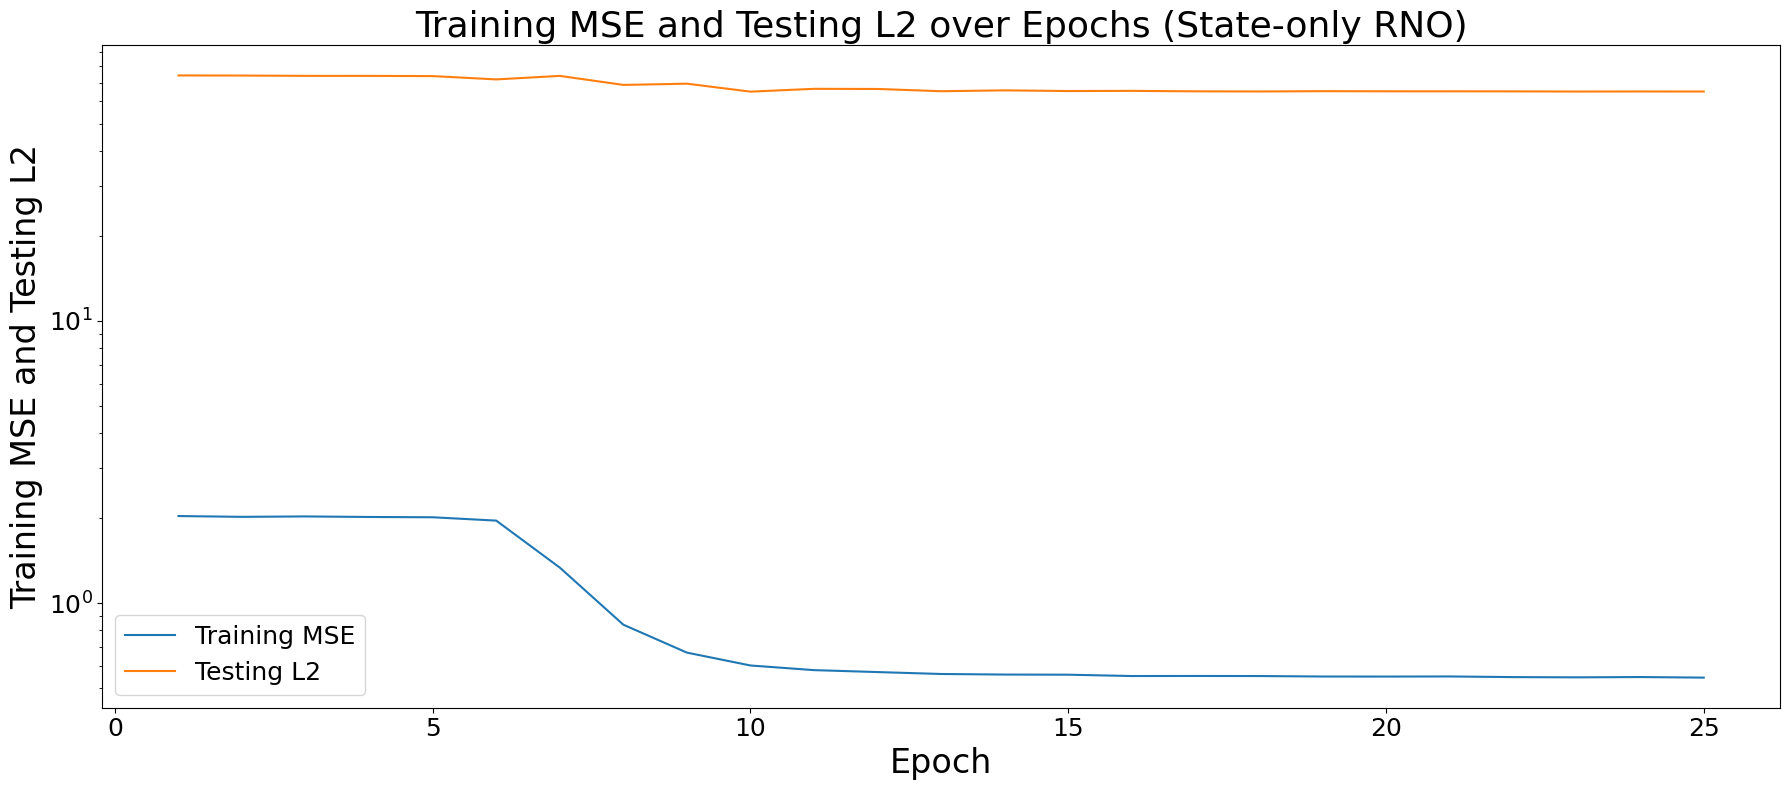

Plots saved to result_rno_state_only_32/train_and_test_loss_plots.png


In [9]:
# 9) Plot training progress (same style family as original notebooks)
df = pd.read_csv(log_file)
fig, (ax1) = plt.subplots(1, 1, figsize=(18, 8), dpi=100)
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

ax1.plot(
    df["epoch"],
    df["loss_train_mse"],
    label="Training MSE",
    color=colors[0],
    linestyle="-",
)
ax1.plot(
    df["epoch"],
    df["loss_test_l2"],
    label="Testing L2",
    color=colors[1],
    linestyle="-",
)
ax1.set_yscale("log")
ax1.set_xlabel("Epoch", fontsize=24)
ax1.set_ylabel("Training MSE and Testing L2", fontsize=24)
ax1.set_title("Training MSE and Testing L2 over Epochs (State-only RNO)", fontsize=26)
ax1.legend(loc="best", fontsize=18)
ax1.tick_params(axis="both", which="major", labelsize=18)

plt.tight_layout()
plot_path = os.path.join(result_dir, "train_and_test_loss_plots.png")
plt.savefig(plot_path, dpi=100)
plt.show()
plt.close(fig)
print(f"Plots saved to {plot_path}")


In [10]:
# 10) Save model checkpoint
model_path = os.path.join(result_dir, "rno_state_only_last.pt")
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "model_kwargs": {
            "n_modes": (modes1, modes2),
            "hidden_channels": width,
            "in_channels": 1,
            "out_channels": 1,
            "n_layers": n_layers,
            "domain_padding": domain_padding,
        },
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "seed": seed,
        "epochs": epochs,
        "config": {
            "modes1": modes1,
            "modes2": modes2,
            "width": width,
            "n_layers": n_layers,
            "domain_padding": domain_padding,
            "in_channels": 1,
            "out_channels": 1,
            "chunk_len": chunk_len,
            "n_intervals": n_intervals,
            "sub": sub,
            "train_frac": train_frac,
        },
        "train_loss_history": training_loss_history,
        "test_loss_history": test_loss_history,
    },
    model_path,
)
print(f"Saved checkpoint to {model_path}")


Saved checkpoint to result_rno_state_only_32/rno_state_only_last.pt
